<a href="https://colab.research.google.com/github/23170102/EDMUNDODICK/blob/master/Dataset_Mobile_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

================ ESTADÍSTICA DESCRIPTIVA ================
Resumen numérico de todo el dataset (Primeras 10 columnas):
       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000     1.0000     2.200000     1.000000     7.000000   
max      1998.000000     1.0000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  
mean      0.521500    32.046500     0.501750   140.249000     4.52050

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


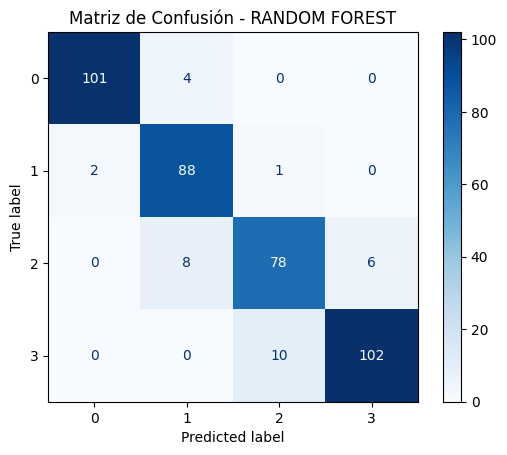


================ RESULTADOS: MULTI-LAYER PERCEPTRON ================
[+] Reporte de Clasificación (Función de Evaluación):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       105
           1       0.94      0.99      0.96        91
           2       0.94      0.89      0.92        92
           3       0.96      0.96      0.96       112

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

------------------------------------------------------


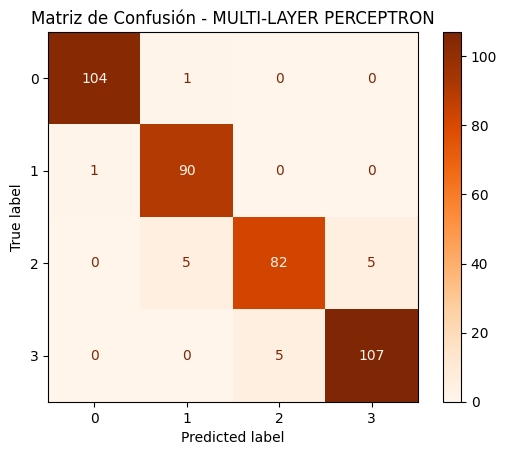


================ ANÁLISIS DE CARACTERÍSTICAS ================
¿Qué peso le dio el Random Forest a cada característica?
- RAM: 67.14% de importancia
- BATTERY_POWER: 11.86% de importancia
- PX_HEIGHT: 8.56% de importancia
- PX_WIDTH: 7.94% de importancia
- INT_MEMORY: 4.50% de importancia


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ==========================================
# 1. CARGAR EL DATASET DESDE INTERNET (Automático)
# ==========================================
# Ya no necesitamos subir el archivo manualmente, Pandas lo descarga directo de GitHub
url = 'https://raw.githubusercontent.com/23170102/Practica-Clasificacion-IA-Mobile-Price/refs/heads/main/train.csv'
df = pd.read_csv(url)

# ==========================================
# ESTADÍSTICA DESCRIPTIVA (EDA)
# ==========================================
print("================ ESTADÍSTICA DESCRIPTIVA ================")
print("Resumen numérico de todo el dataset (Primeras 10 columnas):")
print(df.iloc[:, :10].describe())
print("------------------------------------------------------\n")

# 2. SELECCIÓN DE CARACTERÍSTICAS
mejores_features = ['ram', 'battery_power', 'px_height', 'px_width', 'int_memory']
X = df[mejores_features]
y = df['price_range'] # Clases: 0 (bajo), 1 (medio), 2 (alto), 3 (muy alto)

# 3. DIVIDIR EN ENTRENAMIENTO (80%) Y PRUEBA (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. ESCALAR LOS DATOS (Crucial para el MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODELO 1: RANDOM FOREST (RF)
# ==========================================
print("--- ENTRENANDO RANDOM FOREST ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ==========================================
# MODELO 2: MULTI-LAYER PERCEPTRON (MLP)
# ==========================================
print("\n--- ENTRENANDO MULTI-LAYER PERCEPTRON (Red Neuronal) ---")
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
mlp_pred = mlp_model.predict(X_test_scaled)

# ==========================================
# FUNCIONES DE EVALUACIÓN Y MATRICES GRÁFICAS
# ==========================================
def evaluar_y_graficar(nombre, y_verdadero, y_prediccion, color_map):
    print(f"\n================ RESULTADOS: {nombre} ================")
    print("[+] Reporte de Clasificación (Función de Evaluación):")
    print(classification_report(y_verdadero, y_prediccion))
    print("------------------------------------------------------")

    # Generar la gráfica de la matriz de confusión
    disp = ConfusionMatrixDisplay.from_predictions(y_verdadero, y_prediccion, cmap=color_map)
    disp.ax_.set_title(f'Matriz de Confusión - {nombre}')
    plt.show()

# Ejecutar las evaluaciones y mostrar gráficas
evaluar_y_graficar("RANDOM FOREST", y_test, rf_pred, plt.cm.Blues)
evaluar_y_graficar("MULTI-LAYER PERCEPTRON", y_test, mlp_pred, plt.cm.Oranges)

# ==========================================
# IMPORTANCIA DE LAS CARACTERÍSTICAS (Solo RF)
# ==========================================
print("\n================ ANÁLISIS DE CARACTERÍSTICAS ================")
print("¿Qué peso le dio el Random Forest a cada característica?")
importancias = rf_model.feature_importances_

for caracteristica, importancia in zip(mejores_features, importancias):
    porcentaje = importancia * 100
    print(f"- {caracteristica.upper()}: {porcentaje:.2f}% de importancia")